# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 2 (Часть 2): GCN

### Оценивание и штрафы
Всего заданий: **5**, максимальная оценка — **6 баллов (+2.0 бонус)**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 15.03.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQ2ODc0NzExMTI5/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на основе графовых нейросетей для обучения эмбеддингов на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [44]:
# !pip install torch_geometric

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch_geometric
from scipy.sparse import csr_matrix, bmat
from collections import defaultdict

import torch.nn as nn
import torch.nn.functional as F

from scipy.sparse import diags as sp_diags
from sklearn.metrics import roc_auc_score, average_precision_score

In [46]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:** 
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия 
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


### GCN

В этой части мы будем использовать строить эмбеддинги пользователей и фильмов с помощью графа Лапласиана, чтобы потом на этих эмбеддингах обучать supervised модель, которая уже будет рекомендовать фильмы

### Берем заготовки из ДЗ-1

In [47]:
def precision_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    if k == 0:
        return 0.0
        
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)
    
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / k


def recall_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    if len(relevant_set) == 0:
        return 0.0

    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(relevant_set)

def ap_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    if len(relevant_set) == 0:
        return 0.0

    score = 0.0
    hits = 0

    for i, item in enumerate(recommended_k, start=1):
        if item in relevant_set:
            hits += 1
            score += hits / i 

    return score / min(k, len(relevant_set))

def ndcg_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> float:
    recommended_k = recommended_list[:k]
    relevant_set = set(relevant_items)

    dcg = 0.0
    for i, item in enumerate(recommended_k, start=1):
        rel_i = 1 if item in relevant_set else 0
        if rel_i:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(k, len(relevant_set))
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    return dcg / idcg

def evaluate_model(model, ks=(1, 5, 10, 20, 35, 50)):
    results = {k: [] for k in ks}

    for user in users:
        model._current_user_id = user 
    
        seen = train_user_items.get(user, np.array([]))
        relevant = test_user_items.get(user, np.array([]))


        if len(relevant) == 0:
            continue

        for k in ks:
            recs = model.predict(seen, k)
            metrics = evaluate_recommender(recs, relevant, k)
            results[k].append(metrics)

    avg = {}
    for k in ks:
        avg[k] = {
            m: np.mean([r[m] for r in results[k]])
            for m in ["precision@k", "recall@k", "ap@k", "ndcg@k"]
        }

    return avg

def evaluate_recommender(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10,
) -> dict:
    return {
        "precision@k": precision_at_k(recommended_list, relevant_items, k),
        "recall@k": recall_at_k(recommended_list, relevant_items, k),
        "ap@k": ap_at_k(recommended_list, relevant_items, k),
        "ndcg@k": ndcg_at_k(recommended_list, relevant_items, k),
    }

def plot_scores(scores, title):
    ks = sorted(scores.keys())
    metrics = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

    plt.figure()
    for m in metrics:
        values = [scores[k][m] for k in ks]
        plt.plot(ks, values, marker="o", label=m)

    plt.xticks(ks)
    
    plt.xlabel("K")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

**Задание 0 (1 балл):** Как и в первой части ДЗ-2, вам необходимо построить двудольный граф взаимодействий `user-item` (берем оценки $\geqslant 4$ по `rating_5`). Убедитесь, что индексы узлов перекодированы в непрерывный диапозон от $0$ до $N-1$, где $N$ - количество пользователей и фильмов. 

In [48]:
ratings_train = pd.read_csv(
    "data/ydata-ymovies-user-movie-ratings-train-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating_13", "rating_5"],
)

ratings_test = pd.read_csv(
    "data/ydata-ymovies-user-movie-ratings-test-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating_13", "rating_5"],
)

In [49]:
train_user_items = defaultdict(list)
test_user_items = defaultdict(list)

for _, row in ratings_train.loc[ratings_train["rating_5"] >= 4].iterrows():
    if row.user_id in user2idx and row.movie_id in movie2idx:
        u = user2idx[row.user_id]
        m = movie2idx[row.movie_id]
        train_user_items[u].append(m)

for _, row in ratings_test.loc[ratings_test["rating_5"] >= 4].iterrows():
    if row.user_id in user2idx and row.movie_id in movie2idx:
        u = user2idx[row.user_id]
        m = movie2idx[row.movie_id]
        test_user_items[u].append(m)

train_user_items = {u: np.array(sorted(set(v)), dtype=int) for u, v in train_user_items.items()}
test_user_items = {u: np.array(sorted(set(v)), dtype=int) for u, v in test_user_items.items()}

users = sorted(test_user_items.keys())

print("Users with test positives:", len(users))

Users with test positives: 2044


In [50]:
train_pos = ratings_train.loc[ratings_train["rating_5"] >= 4, ["user_id", "movie_id"]].dropna()
train_pos = train_pos.drop_duplicates(subset=["user_id", "movie_id"])

user_ids = np.sort(train_pos["user_id"].unique())
movie_ids = np.sort(train_pos["movie_id"].unique())

U = len(user_ids)
M = len(movie_ids)

user2idx = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}

u_idx = train_pos["user_id"].map(user2idx).to_numpy()
m_idx = train_pos["movie_id"].map(movie2idx).to_numpy()

data = np.ones(len(train_pos), dtype=np.uint8)
B = csr_matrix((data, (u_idx, m_idx)), shape=(U, M))

Zuu = csr_matrix((U, U), dtype=np.uint8)
Zmm = csr_matrix((M, M), dtype=np.uint8)

A = bmat([[Zuu, B],
          [B.T, Zmm]], format="csr", dtype=np.uint8)

print(f"Users: {U}, Movies: {M}")
print(f"B shape: {B.shape}, nnz: {B.nnz}")
print(f"A shape: {A.shape}, nnz: {A.nnz}")

train_user_items = (
    train_pos.assign(u=u_idx, m=m_idx)
            .groupby("u")["m"]
            .apply(lambda x: np.array(sorted(set(x)), dtype=int))
            .to_dict()
)

test_pos = ratings_test.loc[ratings_test["rating_5"] >= 4, ["user_id", "movie_id"]].dropna()
test_pos = test_pos[
    test_pos["user_id"].isin(user2idx.keys()) &
    test_pos["movie_id"].isin(movie2idx.keys())
].drop_duplicates(subset=["user_id", "movie_id"])

test_pos["u"] = test_pos["user_id"].map(user2idx)
test_pos["m"] = test_pos["movie_id"].map(movie2idx)

test_user_items = (
    test_pos.groupby("u")["m"]
            .apply(lambda x: np.array(sorted(set(x)), dtype=int))
            .to_dict()
)

users = sorted(test_user_items.keys())
print("Users with test positives:", len(users))

Users: 7637, Movies: 10340
B shape: (7637, 10340), nnz: 165566
A shape: (17977, 17977), nnz: 331132
Users with test positives: 2044


**Задание 1 (2 балла):** Обучать GCN будем для предсказаний связей в графе (Link Prediction)

Реализация модели:
- Инициализируйте случайные обучаемые эмбеддинги для пользователей и айтемов
- Реализуйте базовую графовую модель (простой Message Passing), которая обновляет эмбеддинги на основе структуры графа. Используйте матрицы весов и функции активации на каждом слое
- В качестве декодера используйте скалярное произведение: предсказание для пары $u$ и $i$ вычисляется как $E_u \cdot E_i$. Также можете использовать идеи из 1 части ДЗ-2

In [51]:
train_pos = ratings_train.loc[
    ratings_train["rating_5"] >= 4, ["user_id", "movie_id"]
].dropna().drop_duplicates()

user_ids = np.sort(train_pos["user_id"].unique())
movie_ids = np.sort(train_pos["movie_id"].unique())

U = len(user_ids)
M = len(movie_ids)

user2idx = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}

u_idx = train_pos["user_id"].map(user2idx).astype(int).to_numpy()
m_idx = train_pos["movie_id"].map(movie2idx).astype(int).to_numpy()

data = np.ones(len(train_pos), dtype=np.uint8)
B = csr_matrix((data, (u_idx, m_idx)), shape=(U, M))

Zuu = csr_matrix((U, U), dtype=np.uint8)
Zmm = csr_matrix((M, M), dtype=np.uint8)

A = bmat([[Zuu, B],
          [B.T, Zmm]], format="csr", dtype=np.uint8)

print(f"Users: {U}, Movies: {M}")
print(f"B shape: {B.shape}, nnz: {B.nnz}")
print(f"A shape: {A.shape}, nnz: {A.nnz}")

test_pos = ratings_test.loc[
    ratings_test["rating_5"] >= 4, ["user_id", "movie_id"]
].dropna()

test_pos = test_pos[
    test_pos["user_id"].isin(user2idx.keys()) &
    test_pos["movie_id"].isin(movie2idx.keys())
].drop_duplicates()

print("Test positives (filtered):", len(test_pos))

test_pos["u"] = test_pos["user_id"].map(user2idx).astype(int)
test_pos["m"] = test_pos["movie_id"].map(movie2idx).astype(int)

print("Users with test positives:", test_pos["u"].nunique())

Users: 7637, Movies: 10340
B shape: (7637, 10340), nnz: 165566
A shape: (17977, 17977), nnz: 331132
Test positives (filtered): 8155
Users with test positives: 2044


In [52]:
def normalize_adj_sym(A: csr_matrix, eps: float = 1e-12) -> csr_matrix:
    deg = np.asarray(A.sum(axis=1)).ravel().astype(np.float64)
    inv_sqrt = np.zeros_like(deg)
    mask = deg > 0
    inv_sqrt[mask] = 1.0 / np.sqrt(deg[mask] + eps)
    D_inv_sqrt = sp_diags(inv_sqrt)
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    return A_hat.tocsr()

def scipy_csr_to_torch_sparse(A: csr_matrix) -> torch.Tensor:
    A = A.tocoo()
    indices = torch.from_numpy(np.vstack([A.row, A.col]).astype(np.int64))
    values = torch.from_numpy(A.data.astype(np.float32))
    shape = torch.Size(A.shape)
    return torch.sparse_coo_tensor(indices, values, shape).coalesce()

pos_u = train_pos["user_id"].map(user2idx).to_numpy()
pos_m = train_pos["movie_id"].map(movie2idx).to_numpy()
pos_u = pos_u.astype(int)
pos_m = pos_m.astype(int)

pos_set = set(zip(pos_u.tolist(), pos_m.tolist()))

def sample_negatives(n_samples: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    neg_u = np.empty(n_samples, dtype=np.int32)
    neg_m = np.empty(n_samples, dtype=np.int32)
    filled = 0
    while filled < n_samples:
        u = int(rng.integers(0, U))
        m = int(rng.integers(0, M))
        if (u, m) not in pos_set:
            neg_u[filled] = u
            neg_m[filled] = m
            filled += 1
    return neg_u, neg_m

A_hat = normalize_adj_sym(A.astype(np.float64))
A_hat_sp = scipy_csr_to_torch_sparse(A_hat)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
A_hat_sp = A_hat_sp.to(device)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=True)
        self.dropout = dropout

    def forward(self, X, A_hat_sp):
        X = F.dropout(X, p=self.dropout, training=self.training)
        X = torch.sparse.mm(A_hat_sp, X)    
        X = self.lin(X)                     
        return X

class LinkPredGCN(nn.Module):
    def __init__(self, n_users, n_items, hidden_dim=64, n_layers=2, dropout=0.1):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_nodes = n_users + n_items

        self.emb = nn.Embedding(self.n_nodes, hidden_dim)

        layers = []
        for _ in range(n_layers):
            layers.append(GCNLayer(hidden_dim, hidden_dim, dropout=dropout))
        self.layers = nn.ModuleList(layers)

    def forward(self, A_hat_sp):
        X = self.emb.weight 
        for layer in self.layers:
            X = layer(X, A_hat_sp)
            X = F.relu(X)
        return X 

    def score_pairs(self, Z, u_idx, m_idx):
        u = Z[u_idx]
        i = Z[self.n_users + m_idx]
        return (u * i).sum(dim=1)

model = LinkPredGCN(U, M, hidden_dim=64, n_layers=1, dropout=0.1).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

batch_size = 8192
neg_ratio = 2 

pos_u_t = torch.from_numpy(pos_u).long().to(device)
pos_m_t = torch.from_numpy(pos_m).long().to(device)

def iterate_minibatches(n_pos, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_pos)
    rng.shuffle(idx)
    for start in range(0, n_pos, batch_size):
        yield idx[start:start+batch_size]

test_pos_local = test_pos.copy()
test_pos_local["u"] = test_pos_local["user_id"].map(user2idx)
test_pos_local["m"] = test_pos_local["movie_id"].map(movie2idx)
test_pos_local = test_pos_local.dropna()
val_u = test_pos_local["u"].astype(int).to_numpy()
val_m = test_pos_local["m"].astype(int).to_numpy()

val_u_t = torch.from_numpy(val_u).long().to(device)
val_m_t = torch.from_numpy(val_m).long().to(device)

@torch.no_grad()
def evaluate_linkpred():
    model.eval()
    Z = model(A_hat_sp)

    pos_logits = model.score_pairs(Z, val_u_t, val_m_t)
    pos_probs = torch.sigmoid(pos_logits).detach().cpu().numpy()
    y_pos = np.ones_like(pos_probs)

    neg_u_np, neg_m_np = sample_negatives(len(val_u), seed=123)
    neg_u_t = torch.from_numpy(neg_u_np).long().to(device)
    neg_m_t = torch.from_numpy(neg_m_np).long().to(device)

    neg_logits = model.score_pairs(Z, neg_u_t, neg_m_t)
    neg_probs = torch.sigmoid(neg_logits).detach().cpu().numpy()
    y_neg = np.zeros_like(neg_probs)

    y_true = np.concatenate([y_pos, y_neg])
    y_score = np.concatenate([pos_probs, neg_probs])

    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    return auc, ap

epochs = 13
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for bidx in iterate_minibatches(len(pos_u), batch_size, seed=epoch):
        Z = model(A_hat_sp)

        bu = pos_u_t[bidx]
        bm = pos_m_t[bidx]

        n_neg = len(bidx) * neg_ratio
        neg_u_np, neg_m_np = sample_negatives(n_neg, seed=epoch * 1000 + n_batches)
        nu = torch.from_numpy(neg_u_np).long().to(device)
        nm = torch.from_numpy(neg_m_np).long().to(device)

        pos_logits = model.score_pairs(Z, bu, bm)
        neg_logits = model.score_pairs(Z, nu, nm)

        logits = torch.cat([pos_logits, neg_logits], dim=0)
        labels = torch.cat([
            torch.ones_like(pos_logits),
            torch.zeros_like(neg_logits)
        ], dim=0)

        loss = F.binary_cross_entropy_with_logits(logits, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()
        n_batches += 1

    auc, ap = evaluate_linkpred()
    print(f"Epoch {epoch:02d} | loss={total_loss/n_batches:.4f} | val AUC={auc:.4f} | val AP={ap:.4f}")

Epoch 01 | loss=0.7255 | val AUC=0.6957 | val AP=0.7134
Epoch 02 | loss=0.6777 | val AUC=0.7695 | val AP=0.7957
Epoch 03 | loss=0.6444 | val AUC=0.8083 | val AP=0.8320
Epoch 04 | loss=0.6257 | val AUC=0.8279 | val AP=0.8498
Epoch 05 | loss=0.6137 | val AUC=0.8429 | val AP=0.8619
Epoch 06 | loss=0.6062 | val AUC=0.8528 | val AP=0.8697
Epoch 07 | loss=0.6015 | val AUC=0.8589 | val AP=0.8748
Epoch 08 | loss=0.5967 | val AUC=0.8616 | val AP=0.8775
Epoch 09 | loss=0.5946 | val AUC=0.8624 | val AP=0.8789
Epoch 10 | loss=0.5925 | val AUC=0.8672 | val AP=0.8822
Epoch 11 | loss=0.5913 | val AUC=0.8694 | val AP=0.8837
Epoch 12 | loss=0.5894 | val AUC=0.8693 | val AP=0.8838
Epoch 13 | loss=0.5879 | val AUC=0.8711 | val AP=0.8850


### За 13 эпох наблюдается стабильное обучение (дальше пробовал - начинается переобучение).

### Loss (train) монотонно уменьшается. Это означает, что модель всё лучше разделяет положительные и отрицательные пары в задаче предсказания ребра.

### AUC (validation) растёт в первые эпохи и затем выходит на плато. Таким образом, модель с высокой вероятностью ранжирует истинные рёбра выше случайных нерёбер. Значения около 0.87 означают хорошую разделимость классов в задаче предсказания ребер.

### AP (validation) аналогично растет и выходит на плато. AP близка к AUC и также находится на высоком уровне, что говорит о хорошем качестве ранжирования и высокой точности на позитивном классе при разных порогах.

### GCN успешно обучается решать задачу предсказания связей в user–movie графе по позитивным взаимодействиям (rating_5 ≥ 4). Валидационные метрики достигают высоких значений (AUC = 0.87, AP = 0.88) и стабилизируются, что указывает на хорошее качество эмбеддингов и пригодность модели.

Поэксперементировал с 2-мя слоями, но ничего хорошего не получилось, так как два слоя делают более сильное сглаживание (oversmoothing) и представления пользователей и фильмов начинают становиться слишком похожими, теряется различимость (AUC падал за 2-3 эпохи). А один слой даёт достаточно “сообщений” от соседей и при этом не размывает структуру.

На двудольном графе один шаг message passing уже делает необходимое: user получает агрегат по лайкнутым фильмам, а movie получает агрегат по лайкнувшим пользователям. А второй шаг уже может начинать “усреднять” через соседей соседей и ухудшать ранжирование. Что и случилось.

**Задание 2 (2 балла):**  Реализуйте генератор негативных примеров (Negative Sampler) на этапе обучения. На каждое реальное взаимодействие (позитивное ребро) модель должна видеть одно или несколько несуществующих взаимодействий (негативные ребра). Можете взять из 1 части ДЗ-2

Используйте функцию потерь для ранжирования: BPR Loss (Bayesian Personalized Ranking) или BCE Loss (Binary Cross-Entropy) и обучите свою модель

In [53]:
pos_u = train_pos["user_id"].map(user2idx).astype(int).to_numpy()
pos_m = train_pos["movie_id"].map(movie2idx).astype(int).to_numpy()

pos_set = set(zip(pos_u.tolist(), pos_m.tolist()))

class NegativeSampler:
    def __init__(self, n_users, n_items, positive_set, seed=42):
        self.U = n_users
        self.M = n_items
        self.pos_set = positive_set
        self.rng = np.random.default_rng(seed)

    def sample(self, users: np.ndarray, K: int = 1):
        batch = len(users)
        neg_items = np.empty((batch, K), dtype=np.int32)

        for b, u in enumerate(users):
            for k in range(K):
                while True:
                    m = int(self.rng.integers(0, self.M))
                    if (int(u), m) not in self.pos_set:
                        neg_items[b, k] = m
                        break
        return neg_items

neg_sampler = NegativeSampler(U, M, pos_set, seed=42)

In [55]:
def bce_loss(pos_scores: torch.Tensor, neg_scores: torch.Tensor) -> torch.Tensor:
    if neg_scores.dim() == 2:
        neg_scores = neg_scores.reshape(-1)
        pos_scores_rep = pos_scores.repeat_interleave(neg_scores.numel() // pos_scores.numel())
    else:
        pos_scores_rep = pos_scores

    logits = torch.cat([pos_scores_rep, neg_scores], dim=0)
    labels = torch.cat([
        torch.ones_like(pos_scores_rep),
        torch.zeros_like(neg_scores)
    ], dim=0)

    return F.binary_cross_entropy_with_logits(logits, labels)

In [54]:
def bpr_loss(pos_scores: torch.Tensor, neg_scores: torch.Tensor) -> torch.Tensor:
    if neg_scores.dim() == 2: 
        neg_scores = neg_scores.mean(dim=1)
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-12).mean()

In [56]:
model = LinkPredGCN(U, M, hidden_dim=64, n_layers=1, dropout=0.1).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

batch_size = 4096
K_neg = 2           
loss_type = "bpr"   

pos_u_t = torch.from_numpy(pos_u).long().to(device)
pos_m_t = torch.from_numpy(pos_m).long().to(device)

def iterate_minibatches(n_pos, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_pos)
    rng.shuffle(idx)
    for start in range(0, n_pos, batch_size):
        yield idx[start:start+batch_size]

for epoch in range(1, 11):
    model.train()
    total = 0.0
    nb = 0

    for bidx in iterate_minibatches(len(pos_u), batch_size, seed=epoch):
        bu = pos_u[bidx]     
        bm = pos_m[bidx]

        neg_m = neg_sampler.sample(bu, K=K_neg)

        bu_t = torch.from_numpy(bu).long().to(device)
        bm_t = torch.from_numpy(bm).long().to(device)
        neg_m_t = torch.from_numpy(neg_m).long().to(device)  

        Z = model(A_hat_sp)

        pos_scores = model.score_pairs(Z, bu_t, bm_t)  
        neg_scores = []
        for k in range(K_neg):
            neg_scores.append(model.score_pairs(Z, bu_t, neg_m_t[:, k]))
        neg_scores = torch.stack(neg_scores, dim=1)  

        if loss_type == "bpr":
            loss = bpr_loss(pos_scores, neg_scores)
        else:
            loss = bce_loss(pos_scores, neg_scores)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()
        nb += 1

    print(f"Epoch {epoch:02d} | loss={total/nb:.4f} | loss_type={loss_type} | K_neg={K_neg}")

Epoch 01 | loss=0.5167 | loss_type=bpr | K_neg=2
Epoch 02 | loss=0.2650 | loss_type=bpr | K_neg=2
Epoch 03 | loss=0.2151 | loss_type=bpr | K_neg=2
Epoch 04 | loss=0.1893 | loss_type=bpr | K_neg=2
Epoch 05 | loss=0.1744 | loss_type=bpr | K_neg=2
Epoch 06 | loss=0.1627 | loss_type=bpr | K_neg=2
Epoch 07 | loss=0.1514 | loss_type=bpr | K_neg=2
Epoch 08 | loss=0.1435 | loss_type=bpr | K_neg=2
Epoch 09 | loss=0.1350 | loss_type=bpr | K_neg=2
Epoch 10 | loss=0.1282 | loss_type=bpr | K_neg=2


### При обучении с BPR loss наблюдается монотонное снижение значения функции потерь с 0.51 до 0.13 за 10 эпох. Это означает, что модель всё лучше выполняет основное ранжировочное требование BPR: для каждого пользователя положительные взаимодействия получают более высокий скор, чем отрицательные (несуществующие) ребра. Падение loss замедляется к концу обучения, что соответствует выходу на плато после быстрого извлечения базового сигнала из графа.

**Задание 3 (1 балл):** Теперь протестируйте свою модель на тестовой выборке с метриками из ДЗ-1

In [57]:
train_pos_local = train_pos.copy()
train_pos_local["u"] = train_pos_local["user_id"].map(user2idx).astype(int)
train_pos_local["m"] = train_pos_local["movie_id"].map(movie2idx).astype(int)

train_user_items = (
    train_pos_local.groupby("u")["m"]
    .apply(lambda x: np.array(sorted(set(x)), dtype=int))
    .to_dict()
)

test_pos_local = test_pos.copy()
test_pos_local["u"] = test_pos_local["user_id"].map(user2idx).astype(int)
test_pos_local["m"] = test_pos_local["movie_id"].map(movie2idx).astype(int)

test_user_items = (
    test_pos_local.groupby("u")["m"]
    .apply(lambda x: np.array(sorted(set(x)), dtype=int))
    .to_dict()
)

users = sorted(test_user_items.keys())
print("Users with test positives:", len(users))

Users with test positives: 2044


In [58]:
class GCNRecommender:
    def __init__(self, gcn_model, A_hat_sp, n_users, n_items, device):
        self.model = gcn_model
        self.A_hat_sp = A_hat_sp
        self.U = n_users
        self.M = n_items
        self.device = device
        self.Z = None  

    @torch.no_grad()
    def precompute_embeddings(self):
        self.model.eval()
        self.Z = self.model(self.A_hat_sp)  

    @torch.no_grad()
    def predict(self, seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        """
        seen_items: np.array внутренних movie-индексов (0..M-1) из TRAIN
        returns: np.array top-k movie-индексов (0..M-1)
        """
        if self.Z is None:
            self.precompute_embeddings()

        u = self._current_user_id

        user_vec = self.Z[u]                 
        item_mat = self.Z[self.U:self.U+self.M]  

        scores = torch.mv(item_mat, user_vec)  

        if seen_items is not None and len(seen_items) > 0:
            scores[torch.as_tensor(seen_items, device=self.device)] = -1e9

        topk = torch.topk(scores, k=min(k, self.M)).indices.detach().cpu().numpy()
        return topk

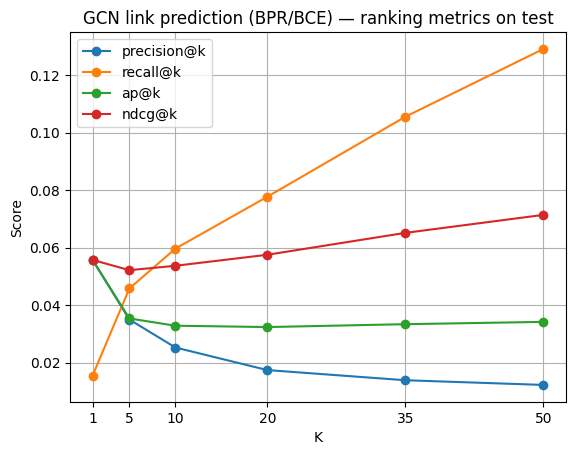

In [59]:
recommender = GCNRecommender(
    gcn_model=model,
    A_hat_sp=A_hat_sp,
    n_users=U,
    n_items=M,
    device=device
)

recommender.precompute_embeddings()

scores = evaluate_model(recommender, ks=(1, 5, 10, 20, 35, 50))
plot_scores(scores, "GCN link prediction (BPR/BCE) — ranking metrics on test")

### GCN-модель для link prediction (обучение с negative sampling и BPR) показала устойчивое качество ранжирования на тесте: при росте K recall@k монотонно увеличивается, а precision@k ожидаемо снижается. Качество порядка рекомендаций ndcg также растёт. В целом модель даёт осмысленные рекомендации и корректно извлекает сигнал из структуры графа.

**Задание 4 (2 балла):** Классический GCN часто страдает от проблемы пересглаживания (over-smoothing) и долго обучается на графах взаимодействий

Реализуйте архитектуру LightGCN, убрав из базовой модели трансформацию признаков (матрицы весов) и нелинейности. Оставьте только взвешенную агрегацию эмбеддингов соседей

Обучите и сравните на тестовой выборке в одинаковых условиях (random seed, lr,  batch_size, etc...) с моделью из задания 1

In [60]:
pos_u = train_pos["user_id"].map(user2idx).astype(int).to_numpy()
pos_m = train_pos["movie_id"].map(movie2idx).astype(int).to_numpy()
pos_set = set(zip(pos_u.tolist(), pos_m.tolist()))

class NegativeSampler:
    def __init__(self, n_users, n_items, positive_set, seed=42):
        self.U = n_users
        self.M = n_items
        self.pos_set = positive_set
        self.rng = np.random.default_rng(seed)

    def sample(self, users: np.ndarray, K: int = 1):
        batch = len(users)
        neg_items = np.empty((batch, K), dtype=np.int32)
        for b, u in enumerate(users):
            for k in range(K):
                while True:
                    m = int(self.rng.integers(0, self.M))
                    if (int(u), m) not in self.pos_set:
                        neg_items[b, k] = m
                        break
        return neg_items

neg_sampler = NegativeSampler(U, M, pos_set, seed=SEED)

In [61]:
class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=64, n_layers=1):
        super().__init__()
        self.U = n_users
        self.M = n_items
        self.N = n_users + n_items
        self.emb = nn.Embedding(self.N, emb_dim)
        nn.init.xavier_uniform_(self.emb.weight)
        self.n_layers = n_layers

    def forward(self, A_hat_sp: torch.Tensor):
        E0 = self.emb.weight                   
        Es = [E0]
        E = E0
        for _ in range(self.n_layers):
            E = torch.sparse.mm(A_hat_sp, E)   
            Es.append(E)
        Z = torch.stack(Es, dim=0).mean(dim=0) 
        return Z

    def score_pairs(self, Z, u_idx, m_idx):
        u = Z[u_idx]                 
        i = Z[self.U + m_idx]        
        return (u * i).sum(dim=1)    

In [64]:
class GraphRecommender:
    def __init__(self, model, A_hat_sp, n_users, n_items, device):
        self.model = model
        self.A_hat_sp = A_hat_sp
        self.U = n_users
        self.M = n_items
        self.device = device
        self.Z = None

    @torch.no_grad()
    def precompute_embeddings(self):
        self.model.eval()
        self.Z = self.model(self.A_hat_sp)

    @torch.no_grad()
    def predict(self, seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        if self.Z is None:
            self.precompute_embeddings()

        u = self._current_user_id
        user_vec = self.Z[u]                            
        item_mat = self.Z[self.U:self.U+self.M]         
        scores = torch.mv(item_mat, user_vec)           

        if seen_items is not None and len(seen_items) > 0:
            scores[torch.as_tensor(seen_items, device=self.device)] = -1e9

        topk = torch.topk(scores, k=min(k, self.M)).indices.detach().cpu().numpy()
        return topk

In [65]:
def iterate_minibatches(n_pos, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_pos)
    rng.shuffle(idx)
    for start in range(0, n_pos, batch_size):
        yield idx[start:start+batch_size]

def train_linkpred_bpr(model, A_hat_sp, device, epochs=13, lr=1e-3, batch_size=4096, K_neg=2):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        nb = 0

        for bidx in iterate_minibatches(len(pos_u), batch_size, seed=SEED + epoch):
            bu = pos_u[bidx]
            bm = pos_m[bidx]
            neg_m = neg_sampler.sample(bu, K=K_neg)

            bu_t = torch.from_numpy(bu).long().to(device)
            bm_t = torch.from_numpy(bm).long().to(device)
            neg_m_t = torch.from_numpy(neg_m).long().to(device)

            Z = model(A_hat_sp)

            pos_scores = model.score_pairs(Z, bu_t, bm_t)
            neg_scores = torch.stack(
                [model.score_pairs(Z, bu_t, neg_m_t[:, k]) for k in range(K_neg)],
                dim=1
            )

            loss = bpr_loss(pos_scores, neg_scores)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item()
            nb += 1

        print(f"Epoch {epoch:02d} | loss={total/nb:.4f}")

    return model

Epoch 01 | loss=0.6814
Epoch 02 | loss=0.5606
Epoch 03 | loss=0.3802
Epoch 04 | loss=0.2728
Epoch 05 | loss=0.2199
Epoch 06 | loss=0.1916
Epoch 07 | loss=0.1746
Epoch 08 | loss=0.1635
Epoch 09 | loss=0.1530
Epoch 10 | loss=0.1481
Epoch 11 | loss=0.1433
Epoch 12 | loss=0.1389
Epoch 13 | loss=0.1328


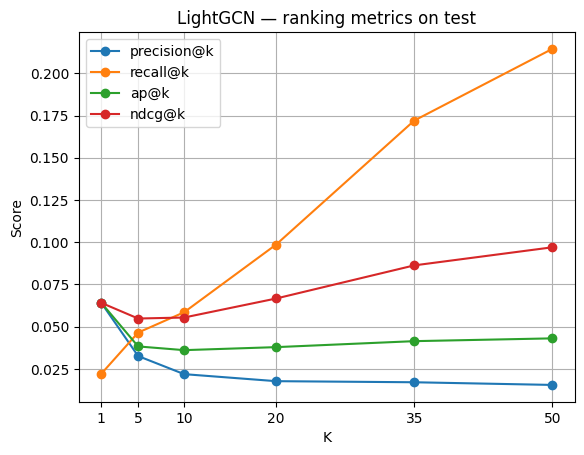

{1: {'precision@k': np.float64(0.06409001956947162),
  'recall@k': np.float64(0.022113425445350735),
  'ap@k': np.float64(0.06409001956947162),
  'ndcg@k': np.float64(0.06409001956947162)},
 5: {'precision@k': np.float64(0.03258317025440313),
  'recall@k': np.float64(0.04648562085158829),
  'ap@k': np.float64(0.03828536094803218),
  'ndcg@k': np.float64(0.054812348778237575)},
 10: {'precision@k': np.float64(0.021868884540117418),
  'recall@k': np.float64(0.05853083385517468),
  'ap@k': np.float64(0.03608312144166212),
  'ndcg@k': np.float64(0.05540676019100363)},
 20: {'precision@k': np.float64(0.017710371819960862),
  'recall@k': np.float64(0.09863404574507181),
  'ap@k': np.float64(0.037869484112283226),
  'ndcg@k': np.float64(0.06667099328702028)},
 35: {'precision@k': np.float64(0.017067374895163544),
  'recall@k': np.float64(0.17201930285378714),
  'ap@k': np.float64(0.0414073801147438),
  'ndcg@k': np.float64(0.08627601532947629)},
 50: {'precision@k': np.float64(0.0154892367906

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lightgcn = LightGCN(U, M, emb_dim=64, n_layers=1)
lightgcn = train_linkpred_bpr(
    lightgcn, A_hat_sp, device,
    epochs=13, lr=1e-3, batch_size=4096, K_neg=2
)

rec_light = GraphRecommender(lightgcn, A_hat_sp, U, M, device)
rec_light.precompute_embeddings()

scores_light = evaluate_model(rec_light, ks=(1,5,10,20,35,50))
plot_scores(scores_light, "LightGCN — ranking metrics on test")
scores_light

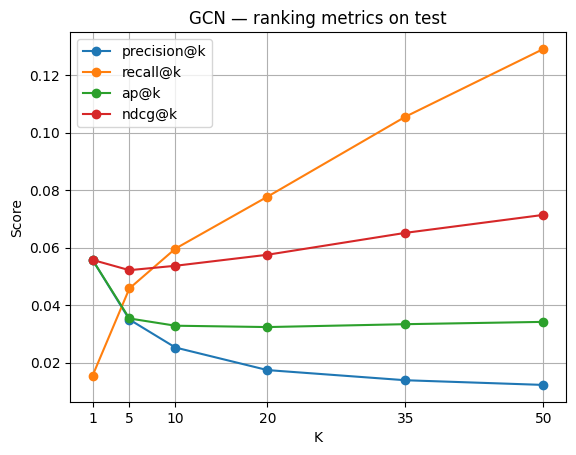

{1: {'precision@k': np.float64(0.05577299412915851),
  'recall@k': np.float64(0.015489298618036069),
  'ap@k': np.float64(0.05577299412915851),
  'ndcg@k': np.float64(0.05577299412915851)},
 5: {'precision@k': np.float64(0.03502935420743639),
  'recall@k': np.float64(0.045835290146691174),
  'ap@k': np.float64(0.03540253315938247),
  'ndcg@k': np.float64(0.052200133090726665)},
 10: {'precision@k': np.float64(0.025293542074363993),
  'recall@k': np.float64(0.0596928122015649),
  'ap@k': np.float64(0.03288025610603015),
  'ndcg@k': np.float64(0.05373043927829566)},
 20: {'precision@k': np.float64(0.017441291585127205),
  'recall@k': np.float64(0.07775930623450909),
  'ap@k': np.float64(0.032408795837593256),
  'ndcg@k': np.float64(0.057566417722154976)},
 35: {'precision@k': np.float64(0.013908303047246297),
  'recall@k': np.float64(0.1055954053038891),
  'ap@k': np.float64(0.033410621526895244),
  'ndcg@k': np.float64(0.06518734758787843)},
 50: {'precision@k': np.float64(0.01227984344

In [82]:
rec_gcn = GraphRecommender(model, A_hat_sp, U, M, device)  
rec_gcn.precompute_embeddings()

scores_gcn = evaluate_model(rec_gcn, ks=(1,5,10,20,35,50))
plot_scores(scores_gcn, "GCN — ranking metrics on test")
scores_gcn

In [68]:
def compact(scores, k):
    return {m: float(scores[k][m]) for m in ["precision@k","recall@k","ap@k","ndcg@k"]}

print("GCN  @10:", compact(scores_gcn, 10))
print("Light@10:", compact(scores_light, 10))
print("GCN  @50:", compact(scores_gcn, 50))
print("Light@50:", compact(scores_light, 50))

GCN  @10: {'precision@k': 0.025293542074363993, 'recall@k': 0.0596928122015649, 'ap@k': 0.03288025610603015, 'ndcg@k': 0.05373043927829566}
Light@10: {'precision@k': 0.021868884540117418, 'recall@k': 0.05853083385517468, 'ap@k': 0.03608312144166212, 'ndcg@k': 0.05540676019100363}
GCN  @50: {'precision@k': 0.012279843444227004, 'recall@k': 0.12917338155489774, 'ap@k': 0.03421454773709294, 'ndcg@k': 0.07143844383193926}
Light@50: {'precision@k': 0.015489236790606653, 'recall@k': 0.21446780409798546, 'ap@k': 0.04305988600149003, 'ndcg@k': 0.09698642292654407}


### При одинаковых условиях обучения (seed, lr, batch_size, negative sampling, BPR) LightGCN показал более высокое качество на тесте. 

### При K=10 он даёт сравнимый recall, но более высокий ap и ndcg; при k=50 превосходит GCN по всем метрикам, особенно по recall и ndcg. 

### Это подтверждает, что упрощение архитектуры до взвешенной агрегации действительно полезно для user–item графов.

**Бонусное задание 2 (2 балла):** Так же, как и в 1 части, давайте добавим признаки пользователей и фильмов. Вам нужно будет продумать преодобработку данных и как лучше их подать модели. Сравните, насколько улучшились или ухудшились рекомендации на тестовой выборке



In [71]:
user_features = pd.read_csv(
    "data/ydata-ymovies-user-demographics-v1_0.txt",
    sep="\t",
    header=None,
    names=["user_id", "year", "gender"],
)
user_features.head()

,user_id,year,gender
0,1,1979,f
1,2,1987,m
2,3,1988,f
3,4,1983,m
4,5,1988,m


In [72]:
user_features["year"] = pd.to_numeric(user_features["year"], errors="coerce")
user_features["age"] = 2005 - user_features["year"]
user_features["age"] = user_features["age"].fillna(user_features["age"].median()).astype(float)

user_features["gender"] = user_features["gender"].astype(str).str.lower().str.strip()
user_features["gender_m"] = (user_features["gender"] == "m").astype(float)

user_feat_df = user_features.set_index("user_id")[["age", "gender_m"]]

In [74]:
cols = [
    "movie_id",
    "title",
    "synopsis",
    "running_time",
    "mpaa_rating",
    "mpaa_reasons",
    "release_date_txt",
    "release_date",
    "distributor",
    "poster_url",
    "genres",
    "directors",
    "director_ids",
    "crew",
    "crew_ids",
    "crew_types",
    "actors",
    "actor_ids",
    "avg_critic_rating",
    "num_critic_ratings",
    "awards_won",
    "awards_nominated",
    "awards_won_list",
    "awards_nominated_list",
    "movie_mom_rating",
    "movie_mom_review",
    "review_summaries",
    "review_owners",
    "trailer_captions",
    "greg_preview_url",
    "dvd_review_url",
    "gnpp",
    "avg_user_rating",
    "num_user_ratings",
]

movie_features = pd.read_csv(
    "data/ydata-ymovies-movie-content-descr-v1_0.txt",
    sep="\t",
    header=None,
    names=cols,
    na_values="\\N",
    encoding="latin-1",
)
movie_features.head()

,movie_id,title,synopsis,running_time,mpaa_rating,mpaa_reasons,release_date_txt,release_date,distributor,poster_url,...,movie_mom_rating,movie_mom_review,review_summaries,review_owners,trailer_captions,greg_preview_url,dvd_review_url,gnpp,avg_user_rating,num_user_ratings
0,1800010969,The 1985 Admiral's Cup (1997),Small boats vs. big winds in this the official...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1800011786,984 - Prisoner of the Future (1984),"984, a man of the future, is imprisoned withou...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1800011850,A's All-Star Almanac (1987),Seen here are great moments from All-Star Game...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.034066,7.0,1.0
3,1800012991,The Adventures of Annie Oakley (1953),"Two great episodes of this western series. ""An...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.743485,6.0,1.0
4,1800013061,The Adventures of Black Beauty 1 (1972),The Fugitive introduces the story of the once ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
mpaa = (
    movie_features["mpaa_rating"]
    .fillna("Unknown")
    .astype(str).str.strip()
    .str.replace(";", "", regex=False)
)

mpaa = mpaa.replace({
    "No Rating": "Unrated",
    "unrated": "Unrated",
    "Not Yet Rated": "Unrated"
})
mpaa = mpaa.str.split().str[0] 
mpaa_dum = pd.get_dummies(mpaa, prefix="mpaa")

genres = movie_features["genres"].fillna("").astype(str).str.strip()
genre_dum = genres.str.get_dummies(sep="|")
if "~Delete" in genre_dum.columns:
    genre_dum = genre_dum.drop(columns=["~Delete"])

movie_feat_df = pd.concat([mpaa_dum, genre_dum], axis=1)
movie_feat_df.index = movie_features["movie_id"]
movie_feat_df = movie_feat_df.fillna(0.0)

In [76]:
Fu = user_feat_df.shape[1]
X_user = np.zeros((U, Fu), dtype=np.float32)

for uid, uix in user2idx.items():
    if uid in user_feat_df.index:
        X_user[uix] = user_feat_df.loc[uid].to_numpy(dtype=np.float32)

Fm = movie_feat_df.shape[1]
X_movie = np.zeros((M, Fm), dtype=np.float32)

for mid, mix in movie2idx.items():
    if mid in movie_feat_df.index:
        X_movie[mix] = movie_feat_df.loc[mid].to_numpy(dtype=np.float32)

print(X_user.shape, X_movie.shape)

(7637, 2) (10340, 31)


In [77]:
class LightGCNWithFeatures(nn.Module):
    def __init__(self, n_users, n_items, user_feat_dim, item_feat_dim, emb_dim=64, n_layers=1):
        super().__init__()
        self.U = n_users
        self.M = n_items
        self.N = n_users + n_items
        self.n_layers = n_layers

        self.user_proj = nn.Linear(user_feat_dim, emb_dim, bias=True)
        self.item_proj = nn.Linear(item_feat_dim, emb_dim, bias=True)

    def forward(self, A_hat_sp, X_user, X_item):
        Eu0 = self.user_proj(X_user)       
        Ei0 = self.item_proj(X_item)        
        E0 = torch.cat([Eu0, Ei0], dim=0)  

        Es = [E0]
        E = E0
        for _ in range(self.n_layers):
            E = torch.sparse.mm(A_hat_sp, E)
            Es.append(E)

        Z = torch.stack(Es, dim=0).mean(dim=0)
        return Z

    def score_pairs(self, Z, u_idx, m_idx):
        u = Z[u_idx]
        i = Z[self.U + m_idx]
        return (u * i).sum(dim=1)

In [78]:
def train_lightgcn_features(
    model, A_hat_sp, X_user_t, X_item_t,
    epochs=13, lr=1e-3, batch_size=4096, K_neg=2
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    for epoch in range(1, epochs+1):
        model.train()
        total, nb = 0.0, 0

        for bidx in iterate_minibatches(len(pos_u), batch_size, seed=SEED + epoch):
            bu = pos_u[bidx]
            bm = pos_m[bidx]
            neg_m = neg_sampler.sample(bu, K=K_neg)

            bu_t = torch.from_numpy(bu).long().to(device)
            bm_t = torch.from_numpy(bm).long().to(device)
            neg_m_t = torch.from_numpy(neg_m).long().to(device)

            Z = model(A_hat_sp, X_user_t, X_item_t)

            pos_scores = model.score_pairs(Z, bu_t, bm_t)
            neg_scores = torch.stack(
                [model.score_pairs(Z, bu_t, neg_m_t[:, k]) for k in range(K_neg)],
                dim=1
            )

            loss = bpr_loss(pos_scores, neg_scores)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item()
            nb += 1

        print(f"Epoch {epoch:02d} | loss={total/nb:.4f}")

    return model

In [80]:
class FeatureGraphRecommender:
    def __init__(self, model, A_hat_sp, X_user_t, X_item_t, n_users, n_items, device):
        self.model = model
        self.A_hat_sp = A_hat_sp
        self.X_user_t = X_user_t
        self.X_item_t = X_item_t
        self.U = n_users
        self.M = n_items
        self.device = device
        self.Z = None

    @torch.no_grad()
    def precompute_embeddings(self):
        self.model.eval()
        self.Z = self.model(self.A_hat_sp, self.X_user_t, self.X_item_t)

    @torch.no_grad()
    def predict(self, seen_items, k=10):
        if self.Z is None:
            self.precompute_embeddings()

        u = self._current_user_id
        user_vec = self.Z[u]
        item_mat = self.Z[self.U:self.U+self.M]
        scores = torch.mv(item_mat, user_vec)

        if seen_items is not None and len(seen_items) > 0:
            scores[torch.as_tensor(seen_items, device=self.device)] = -1e9

        topk = torch.topk(scores, k=min(k, self.M)).indices.detach().cpu().numpy()
        return topk

Epoch 01 | loss=2.4507
Epoch 02 | loss=2.4361
Epoch 03 | loss=2.3804
Epoch 04 | loss=2.3145
Epoch 05 | loss=2.1744
Epoch 06 | loss=1.6354
Epoch 07 | loss=0.8584
Epoch 08 | loss=0.3176
Epoch 09 | loss=0.1946
Epoch 10 | loss=0.1798
Epoch 11 | loss=0.1711
Epoch 12 | loss=0.1676
Epoch 13 | loss=0.1673


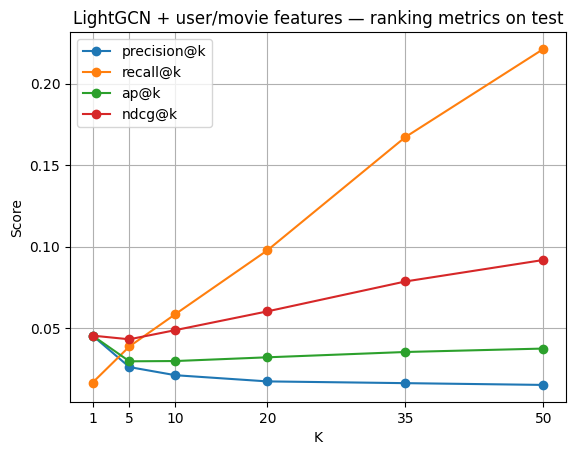

{1: {'precision@k': np.float64(0.045499021526418784),
  'recall@k': np.float64(0.01668903043118628),
  'ap@k': np.float64(0.045499021526418784),
  'ndcg@k': np.float64(0.045499021526418784)},
 5: {'precision@k': np.float64(0.026223091976516635),
  'recall@k': np.float64(0.03884638854742201),
  'ap@k': np.float64(0.02975850728419222),
  'ndcg@k': np.float64(0.04324444359700789)},
 10: {'precision@k': np.float64(0.021232876712328767),
  'recall@k': np.float64(0.058686022088653554),
  'ap@k': np.float64(0.029921509944486602),
  'ndcg@k': np.float64(0.048877017543741276)},
 20: {'precision@k': np.float64(0.0174412915851272),
  'recall@k': np.float64(0.09780143564705768),
  'ap@k': np.float64(0.032209377799893045),
  'ndcg@k': np.float64(0.0603625466434838)},
 35: {'precision@k': np.float64(0.016368465194296897),
  'recall@k': np.float64(0.1672063644373515),
  'ap@k': np.float64(0.03546488631068708),
  'ndcg@k': np.float64(0.07869468902274263)},
 50: {'precision@k': np.float64(0.01528375733

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_user_t = torch.from_numpy(X_user).to(device)
X_item_t = torch.from_numpy(X_movie).to(device)

light_feat = LightGCNWithFeatures(
    U, M,
    user_feat_dim=X_user.shape[1],
    item_feat_dim=X_movie.shape[1],
    emb_dim=64,
    n_layers=1
).to(device)

light_feat = train_lightgcn_features(
    light_feat, A_hat_sp, X_user_t, X_item_t,
    epochs=13, lr=1e-3, batch_size=4096, K_neg=2
)

rec_light_feat = FeatureGraphRecommender(light_feat, A_hat_sp, X_user_t, X_item_t, U, M, device)
rec_light_feat.precompute_embeddings()

scores_light_feat = evaluate_model(rec_light_feat, ks=(1,5,10,20,35,50))
plot_scores(scores_light_feat, "LightGCN + user/movie features — ranking metrics on test")
scores_light_feat

Модель с признаками обучилась корректно (loss упал и стабилизировался).

На тесте она показывает высокий Recall@50 (0.22) при стабильной precision.
При этом AP/NDCG не выросли, а даже стали чуть ниже. То есть прирост в основном в покрытии, а не в качестве ранжирования верхних позиций.

Таким образом, метаданные помогают расширить охват (Recall), то есть модель чаще включает релевантные фильмы в список.

Но они сделали ранжирование менее точным: релевантные фильмы попадают в top-50, но располагаются не так высоко как в предыдущей модели, поэтому AP и
NDCG не выросли.

## Conclusion

Опишите выводы ваших экспериментов:


### GCN для прогнозирования наличия связи между узлами обучается и даёт осмысленные рекомендации. При обучении на позитивных рёбрах (лайки rating_5 ≥ 4) с negative sampling и BPR стабильно улучшала ранжирование. 

### LightGCN оказался эффективнее классического GCN при одинаковых условиях. После удаления нелинейностей и матриц весов (остаётся только взвешенная агрегация соседей) качество рекомендаций улучшилось, особенно на больших списках. Это подтверждает, что для графов взаимодействий user–item упрощённая архитектура лучше избегает пересглаживания и переопределенности.

### Добавление метаданных (демография пользователя + жанры/MPAA фильма) влияет в основном на recall. Инициализация эмбеддингов через признаки позволяет включать больше релевантных фильмов в рекомендации (растёт recall@k, особенно при больших K), однако ранжирование верхних позиций улучшается не всегда: ap@k и ndcg@k меняются умеренно и слегка снижаются. Это означает, что metadata дают дополнительный контентный сигнал, но не заменяют collaborative signal графа.

### Лучшее качество в задаче рекомендаций на графе взаимодействий показал LightGCN. Метаданные оказались полезными как дополнение (особенно для повышения recall), но основной вклад в качество ранжирования всё же даёт структура пользовательских взаимодействий.